In [6]:
import torch
import torch.nn.functional as F
import numpy as np
import timm
import matplotlib.pyplot as plt
# DINOv2
#dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg').to("cuda")
#dinov2_vits14.eval()

from vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_MAP,
    FeatureType,
)

vit_wrapper = PretrainedViTWrapper(MODEL_MAP['LOFTUP_FULL'], add_flash_attn=True, device="cuda")

In [7]:
white_img = np.ones((518,518), np.float16)
white_img_unsq = torch.tensor(white_img).unsqueeze(0).unsqueeze(0).repeat([1,3,1,1])
white_img_unsq.shape

torch.Size([1, 3, 518, 518])

In [3]:
res = vit_wrapper.forward_features(white_img_unsq.to("cuda"), make_2D=True)

In [9]:
res.shape

torch.Size([1, 384, 37, 37])

(array([3.0000e+00, 2.0000e+00, 2.0000e+00, 4.0000e+00, 0.0000e+00,
        1.0000e+00, 4.0000e+00, 1.0000e+00, 2.0000e+00, 1.0000e+00,
        3.0000e+00, 2.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00,
        4.0000e+00, 1.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 2.0000e+00, 6.0000e+00, 5.0000e+00, 2.0000e+00,
        5.0000e+00, 8.0000e+00, 7.0000e+00, 1.6000e+01, 2.0000e+01,
        1.2000e+01, 1.2000e+01, 1.4000e+01, 2.4000e+01, 1.6000e+01,
        2.1000e+01, 2.0000e+01, 3.0000e+01, 3.8000e+01, 3.0000e+01,
        4.5000e+01, 3.3000e+01, 4.4000e+01, 4.8000e+01, 3.6000e+01,
        3.4000e+01, 3.3000e+01, 3.6000e+01, 3.9000e+01, 3.1000e+01,
        4.7000e+01, 5.6000e+01, 5.8000e+01, 4.6000e+01, 4.8000e+01,
        3.6000e+01, 4.7000e+01, 4.5000e+01, 4.9000e+01, 6.5000e+01,
        8.2000e+01, 1.3400e+02, 1.4200e+02, 2.0000e+02, 2.8400e+02,
        3.4400e+02, 4.3500e+02, 5.0300e+02, 6.5200e+02, 9.0400e+02,
        9.9400e+02, 1.1320e+03, 1.5970e+03, 2.26

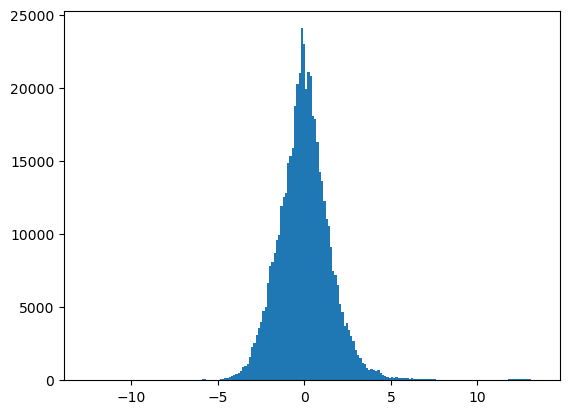

In [10]:
plt.hist(res.flatten().detach().cpu().numpy(), bins=200)

In [11]:
res.detach().cpu().shape

torch.Size([1, 384, 37, 37])

In [19]:
from sklearn.preprocessing import MinMaxScaler

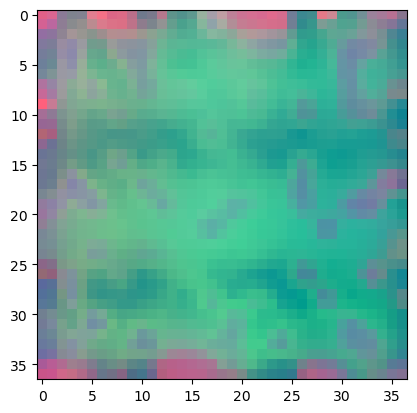

In [24]:
plt_img = np.transpose(res.detach().cpu().numpy().squeeze()[[1,4,10],:,:], (2,1,0)).astype(np.float32)

scaled_plt_img = ((plt_img - plt_img.min())/(plt_img.max()-plt_img.min()))
plt.imshow(scaled_plt_img)

In [13]:
import matplotlib.pyplot as plt

In [14]:
from utils import do_2D_pca

In [37]:
reduced_feats = do_2D_pca(res[0,::], n_components=3, post_norm="minmax")

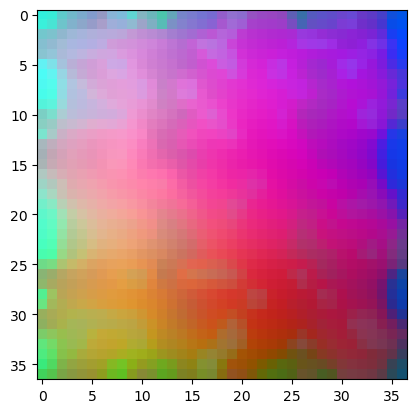

In [38]:
plt.imshow(reduced_feats)